<a href="https://colab.research.google.com/github/bis5742-source/Brooke-Stealey-Midterm-Project-Analysis-of-Consumer-Behavior-and-Campaign-Response-/blob/main/Brooke_Stealey_Midterm_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consumer Behavior and Marketing Response: A Behavorial Analysis of Retail of Customers**

### **Project Overview**

For my midterm project, I want to explore how different consumer behaviors relate to whether a customer responds to a marketing campaign. Since I'm interested in psychology, I want to take a more behavioral approach rather than just describing who spends the most. More specifically, I want to look at how spending habits, browsing patterns, purchasing channels, and deal-seeking behavior may reflect different decision-making tendencies. This gives my project more depth while still staying within an exploratory data analysis framework.

This project uses a retail customer dataset with 2,240 rows and 29 columns, and each row represents one customer. The dataset further includes demographic, household, spending, shopping, and campaign response information. The dataset includes a variable indicating whether a customer responded to the most recent marketing campaign, although the specific details of the purpose of the campaign are not provided.

### **Main Research Question:**

What behavioral patterns are most associated with a customer's likelihood to respond to marketing campaigns?

### **Subquestions**


*   Are customers who spend more overall more likely to respond to a campaign?
*   Does frequent website browsing actually lead to purchases, or does it reflect interest but no action?
*   Are deal-oriented customers more responsive to campaigns than other customers?
*   Do household structure and age seem to have an impact on consumer behavior?
*   Which spending categories appear most associated with campaign response?








### **Methodology**

To answer these questions, I used exploratory data analysis techniques in Python. First, I preped the data set by handling missing values, converting variables such as dates into usable formats, and removing unnecessary columns. I then created several new variables to better capture customer behavior, such as total spending, total purchases, and ratios that reflect browsing versus buying and deal-oriented behavior.

After preparing the data, I used visualizations such as histograms, scatter plots, and boxplots to compare patterns between customers who responded to the campaign and those who did not. I also used grouped summaries to examine how different behavioral and demographic factors relate to response rates.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [ ]:
#load dataset directly from URL
url = 'https://raw.githubusercontent.com/jfkoehler/nyu_bootcamp_spr26/refs/heads/main/data/food_data.csv'
df = pd.read_csv(url)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.shape

(2240, 29)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


The dataset contains customer-level information on demographics, spending, purchases, website activity, and campaign response. This makes it a strong fit for exploratory data analysis because it includes both numeric and categorical variables, along with a clear outcome variable of whether the customer responded to the most recent campaign.

### **Data Prep**

Before analyzing the data, I prepared it by handling the missing values, converting the data types, and removing coulmns that would not be useful in the analysis.

In [ ]:
# check missing values
df.isna().sum().sort_values(ascending=False)

,0
Income,24
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
# drop missing income values
print('Missing Income values before:', df['Income'].isna().sum())

df = df.dropna(subset=['Income']).copy()

print('Missing Income values after:', df['Income'].isna().sum())
print('Shape after dropping missing Income values:', df.shape)

Missing Income values before: 24
Missing Income values after: 0
Shape after dropping missing Income values: (2216, 29)


In [ ]:
# convert date column
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [ ]:
# drop constant columns (not useful)
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'], errors='ignore')
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [ ]:
# check duplicates
print('Duplicate rows:', df.duplicated().sum())

df.info()

Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts    

I removed rows with missing income values because income is important for many of the comparisons in this project. I also converted the customer date column into a datetime format so it can be more easily used, and I removed constant columns because they do not provide any variation across customers.

## **Creating New Variables**

To better analyze customer behavior, I created new variables such as total spending, total purchases, and deal ratio. These help capture broader patterns in how customers shop and respond to marketing.

### **1. Age**

In [ ]:
df['Age'] = 2026 - df['Year_Birth']
df['Age'].head()

,Age
0,69
1,72
2,61
3,42
4,45


I created an age variable from the year of birth to better represent customer demographics.

### **2.** **Total Spending**

In [ ]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

To capture overall comsumtpion, I combined all product category spending into a single total spending variable.

### **3. Total Purchases**

In [ ]:
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

I combined purchases across all channels to measure overall shopping activity.

### **4. Household Structure**



In [ ]:
df['Children_Home'] = df['Kidhome'] + df['Teenhome']

I simplified and created a variable to represent the number of children in the household.

### **5. Past Campaign Behavior**

In [ ]:
df["Total_Accepted_Campaigns"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"]
)

This variable shows how many previous campaigns each customer has accepted.

### **6. Browsing vs Buying Behavior**

In [ ]:
df['Web_Visit_Purchase_Ratio'] = df['NumWebVisitsMonth']/(df['NumWebPurchases']+ 1)
df['Web_Visit_Purchase_Ratio'].head()

,Web_Visit_Purchase_Ratio
0,0.777778
1,2.500000
2,0.444444
3,2.000000
4,0.833333


This variable compares how often a consumer visits the website to how often they actually make purchases. This helps show whether customers are just browsing or if they are actually buying. I added the +1 to the denominator to avoid division by zero for customers with no purchases.

### **7. Deal Oriented Customer**

In [ ]:
df['Deal_Ratio'] = df['NumDealsPurchases'] / (df['Total_Purchases'] + 1)
df['Deal_Oriented'] = np.where(df['Deal_Ratio'] > df['Deal_Ratio'].median(), 1, 0)
df[['Deal_Ratio', 'Deal_Oriented']].head()

,Deal_Ratio,Deal_Oriented
0,0.130435,0
1,0.400000,1
2,0.047619,0
3,0.285714,1
4,0.333333,1


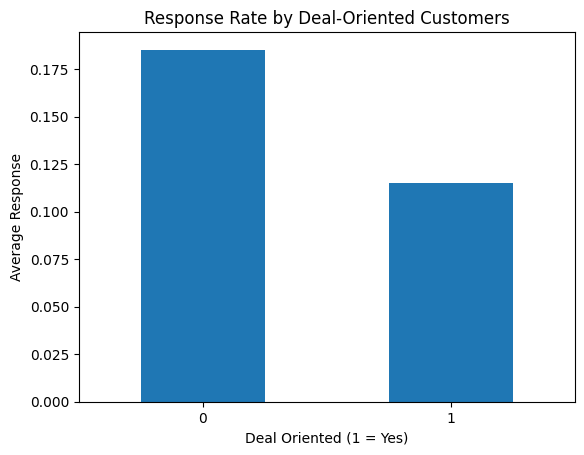

In [ ]:
df.groupby("Deal_Oriented")["Response"].mean().plot(kind="bar")
plt.title("Response Rate by Deal-Oriented Customers")
plt.xlabel("Deal Oriented (1 = Yes)")
plt.ylabel("Average Response")
plt.xticks(rotation=0)
plt.show()

This variables measure how much a customer relies on deals. Customers who have a higher deal ratio are considered more deal-oriented, meaning they may be more influenced by deals promotions or discounts.

## **Initial Analysis**

In [ ]:
df.groupby('Response')[[
    'Income',
    'Age',
    'Total_Spending',
    'Total_Purchases',
    'NumWebVisitsMonth',
    'Deal_Ratio'
]].mean()

,Income,Age,Total_Spending,Total_Purchases,NumWebVisitsMonth,Deal_Ratio
Response,,,,,,
0,50839.132767,57.298991,540.124270,12.062666,5.321296,0.234202
1,60209.675676,56.504505,985.660661,15.354354,5.306306,0.185648


This intitial tables gives us a first look at how customers who responded to the campaign differ from those who did not. By comparing averages across spending, purchasing behavior, and browsing activity, I can begin to see whether certain behavioral patterns are associated with higher responsiveness.

## **Visual Analysis**

### 1. Distribution of Total Spending

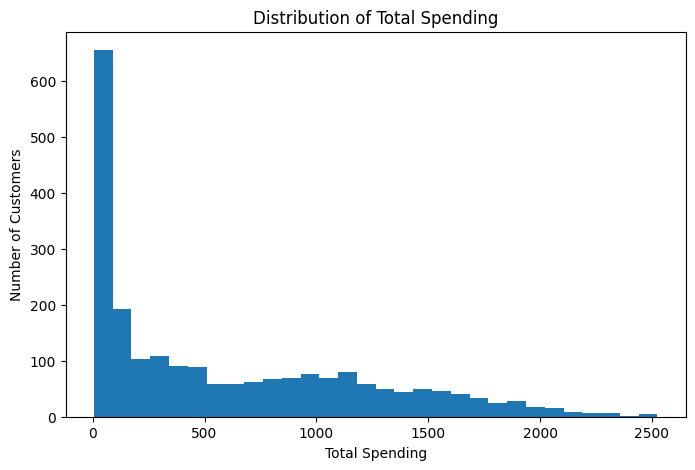

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Total_Spending'], bins = 30)
plt.title('Distribution of Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

The graph shows that the distribution is heavily skewed, with most customers spending relatively low amounts and a smaller group of customers accounting for a much higher spending. This suggests that a small portion of customers may contribute disproportionately to overall revenue.

### 2. Income vs Total Spending

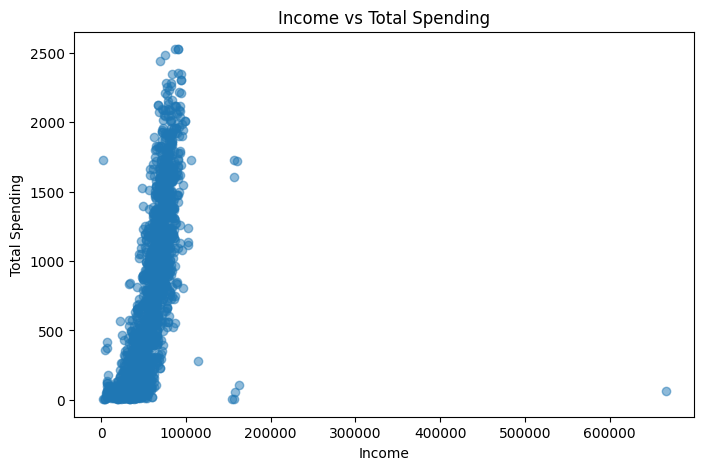

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Income'], df['Total_Spending'], alpha=0.5)
plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.show()

This graph shows a general positive relationship between income and total spending, meaning that higher-income customers tend to spend more overall. However, the wide spread of points suggests that spending behavior varies significantly even among customers with similar income levels. Additonally, there are some outliers, including a very high-income customer with relatively low spending, which shows that income alone does not fully explain purchasing behavior.

### 3. Campaign Response

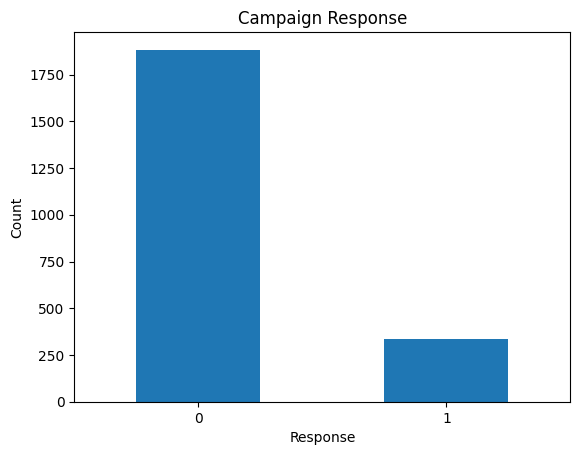

In [ ]:
df['Response'].value_counts().plot(kind='bar')
plt.title('Campaign Response')
plt.xlabel('Response')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

This chart shows that the majority of customers did not respond to the campaign, while only a smaller portion did. This suggests that campaign response is relatively uncommon, making it more important to understand what differentiates the customers who do respond from those who do not.

### 4. Total Spending by Campaign Response

<Figure size 800x500 with 0 Axes>

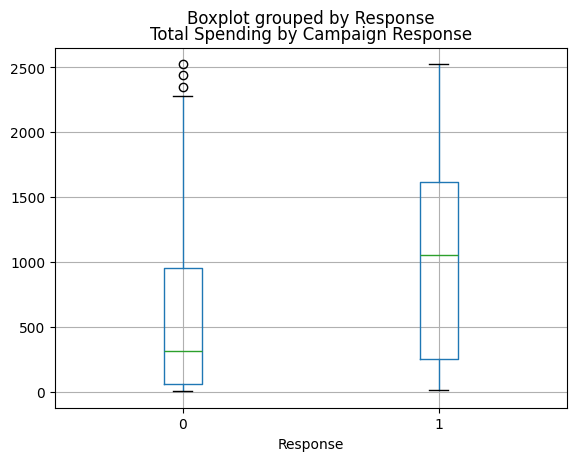

In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column='Total_Spending', by='Response')
plt.title('Total Spending by Campaign Response')
plt.show()

This graph shows a clear difference between customers who responded to the campaign and those who did not. Customers who responded have a much higher median level of spending, suggesting that higher-spending customers are more likely to engage with marketing campaigns. Additionally, the wider spread among responders indicates more variation in their spending behavior, while most non-responders tend to spend less overall despite a few high-spending outliers.

### 5. Total Purchases by Campaign Response

<Figure size 800x500 with 0 Axes>

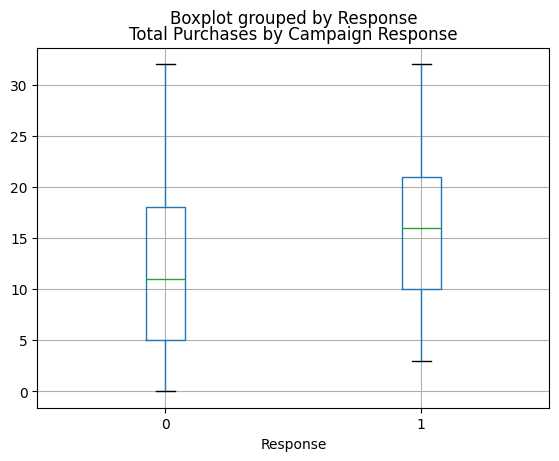

In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column='Total_Purchases', by='Response')
plt.title('Total Purchases by Campaign Response')
plt.show()

This graph shows that customers who responded to the campiagn tend to make more purchases overall. The median number of purchases is noticeably higher for responders, suggesting that they are more active shoppers. This indicates that customers who engaged more frequently with the business are also more likely to respond to marketing efforts.

### 6. Browsing vs Buying Behavior

<Figure size 800x500 with 0 Axes>

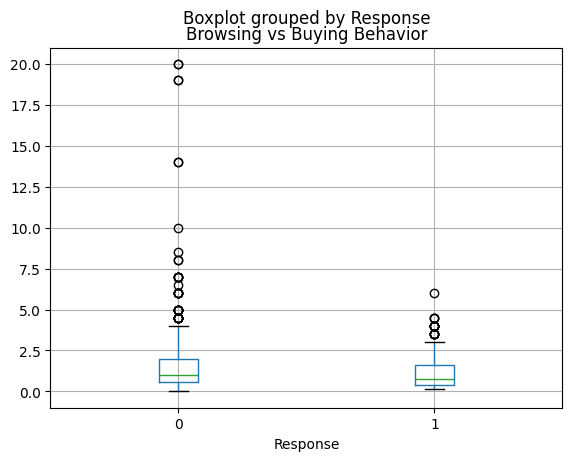

In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column='Web_Visit_Purchase_Ratio', by='Response')
plt.title('Browsing vs Buying Behavior')
plt.show()

The graph compares how often customers visit the website relative to how often they make purchases. Customers who did not respond tend to have higher ratios, meaning they visit the website frequently without making purchases. In contrast, customers who responded have lower ratios, suggesting they are more likely to convert visits into actual purchases. This indicates that browsing behavior alone does not lead to engagement, while purchasing behavior is more strongly associated with campaign response.

### 7. Deal-Oriented Behavior and Response

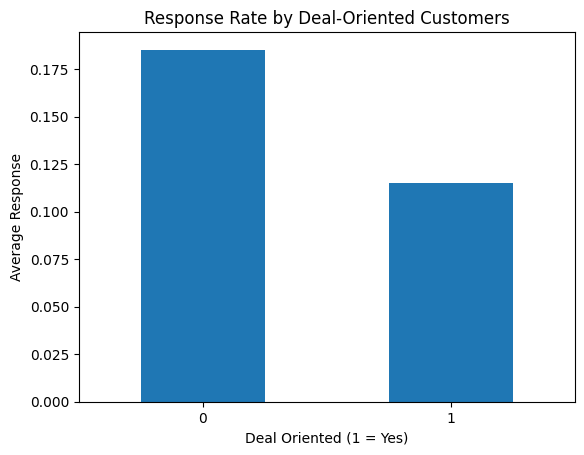

In [ ]:
df.groupby('Deal_Oriented')['Response'].mean().plot(kind='bar')
plt.title('Response Rate by Deal-Oriented Customers')
plt.xlabel('Deal Oriented (1 = Yes)')
plt.ylabel('Average Response')
plt.xticks(rotation=0)
plt.show()

Surprisingly, this graph shows that deal-oriented customers are actually less likely to respond to the campaign compared to non-deal-oriented customers. This suggests that customers who rely hevaily on discounts may be more selective and only respond to specific types of promotions. In contrast, customers who are less focused on deals may be more generally enaged with the brand and therefore more likely to respond to marketing efforts.

### 8. Age and Campaign Response

<Figure size 800x500 with 0 Axes>

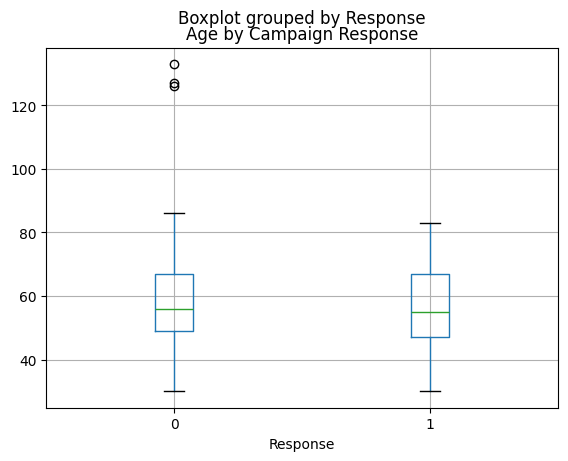

In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column='Age', by='Response')
plt.title('Age by Campaign Response')
plt.show()

This graph shows that the age distribution is very similar between customers responded and those who did not. The medians and overall spread are nearly the same, suggesting that age does not play a significant role in campaign response.This indicates that behavioral spenders, such as spending and purchasing activity, may be more important than demographic characteristics like age.

### 9. Household Strucure and Response

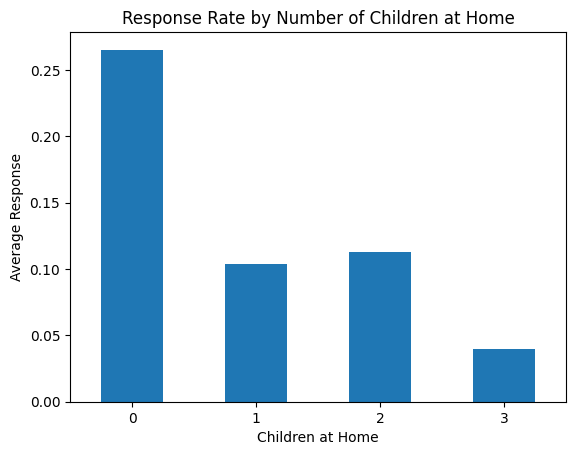

In [ ]:
df.groupby('Children_Home')['Response'].mean().plot(kind='bar')
plt.title('Response Rate by Number of Children at Home')
plt.xlabel('Children at Home')
plt.ylabel('Average Response')
plt.xticks(rotation=0)
plt.show()

This graph shows that customers with fewer children at home are more likely to respond to marketing campaigns. Customers with no children have the highest response rate, while those with more children show lower engagement. This suggests that individuals with fewer household responsibilites may have more time, flexibility, or interest in engaging with marketing efforts.

# **Conclusion**

This project shows that consumer behavior plays a key role in determining market engagement. Customers who spend more and shop more frequently are more likely to respond to campaigns, suggesting that overall activity and involvement with the business are strong indicators of engagement. In contrast, browsing behavior alone is not a strong predictor of response, as many customers visit the website without actually making purchases.

From a behavioral perspective, this suggests that action-based behaviors, such as purchasing, are more important than passive behaviors, such as browsing. While factors like deals and demographics have some influence, they are less important than overall engagement with the business.

These findings highlight the importance of trageting active and high-value customers in marketing strategies, as they are the most likely to respond and generate value. Because the dataset does not specify the type of campaign, the results should be interpreted as general patterns of engagement than responses to a certain marketing strategy. In a real-world context, this suggests that companies should focus their marketing efforts on customers who are already actively engaging with their brand, rather than relying solely on broad outreach strategies.

### **Answering Research and Subquestions**




### Main Research Question:
What behavioral patterns are most associated with a customer's likelihood to respond to marketing campaigns?

The analysis shows that customers who are more engaged with the business, specifically those who spend more and make purchases more frequently, are the most likely to respond to marketing campaigns. Behavioral activity is a stronger indicator of response than demographic characteristics.


### Subquestion 1:
Are customers who spend more overall more likely to respond to a campaign?

Yes, customers who responded to the campaign had significantly higher total spending levels. This suggests that higher-value customers are more engaged and more likely to respond to marketing efforts.


### Subquestion 2:
Does frequent website browsing actually lead to purchases, or does it reflect interest but no action?

Browsing alone does not lead to higher response rates. Customers who browse frequently without purchasing are less likely to respond, while those who convert visits into purchases are more likely to engage. This suggests that purchasing behavior, not browsing, is the stronger indicator of engagement.


### Subquestion 3:
Are deal-oriented customers more responsive to campaigns than other customers?

No, deal-oriented customers were actually less likely to respond to campaigns. This suggests that customers who rely heavily on discounts may be more selective and not as broadly responsive to general marketing efforts.


### Subquestion 4:
Do household structure and age seem to have an impact on consumer behavior?

Age does not appear to have a strong effect on campaign response. However, household structure does show some impact, as customers with fewer children at home are more likely to respond. This suggests that lifestyle factors may influence engagement more than basic demographics.


### Subquestion 5:
Which spending behaviors appear most associated with campaign response?

Overall spending and purchase frequency are the strongest behavioral indicators of response. Customers who are more active and engaged with the business are significantly more likely to respond to marketing campaigns.

### **Limitations**

There are definitely several limitations to this analysis. First, because this is an explanatory analysis, it does identify patterns but it does not establish causation. While certain behaviors are associated with higher response rates, we cannot conclude that they directly cause customers to respond. Further, the dataset does not provide details about the specific purpose of the marketing campaign, which limits the ability to understand what type of messaging or strategy influenced cuonsumer behavior. As a result, the findings should be interpreted as general patterns of engagement. Additionally, the dataset does not include deeper psychlogical or contextual variables, such as customer preferences, motivations, or external factors, which may also influence behavior. Finally, there are a few outliers and data inconsistencies that may sligtly affect the results, although they do not change the overall patterns observed.

# **Streamlit Application**

To extend this project, I created a simple Streamlit application that allows users to interact with the dataset and explore customer behavior dynamically.

The app includes:
- Filtering customers by income and age
- Viewing a preview of the filtered data set
*   Visualizing the relationship between income and spending on a chosen variable (in this case, the variable is wine)


Example code to plug in is below:

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

#load data
url = 'https://raw.githubusercontent.com/jfkoehler/nyu_bootcamp_spr26/refs/heads/main/data/food_data.csv'
df = pd.read_csv(url)

st.title("Customer Behavior and Campaign Response")

# filter by income
income_range = st.slider(
    "Select Income Range",
    int(df["Income"].min()),
    int(df["Income"].max()),
    (20000, 100000)
)

filtered_df = df[
    (df["Income"] >= income_range[0]) &
    (df["Income"] <= income_range[1])
]

st.write("Filtered Data Preview")
st.write(filtered_df.head())

# scatter plot
fig, ax = plt.subplots()
ax.scatter(filtered_df["Income"], filtered_df["MntWines"])
ax.set_xlabel("Income")
ax.set_ylabel("Wine Spending")
ax.set_title("Income vs Wine Spending")

st.pyplot(fig)

This interactive component allows users to go beyond static graphs and explore how different variables relate to purchasing behavior. Instead of only presenting results, the app gives users the ability to adjust inputs and observe how patterns change in real time. This helps provide a clearer understanding of how factors like income influence spending, and more broadly, how customer characteristics may relate to marketing outcomes.

Below is a screenshot of the interactive Streamlit application:

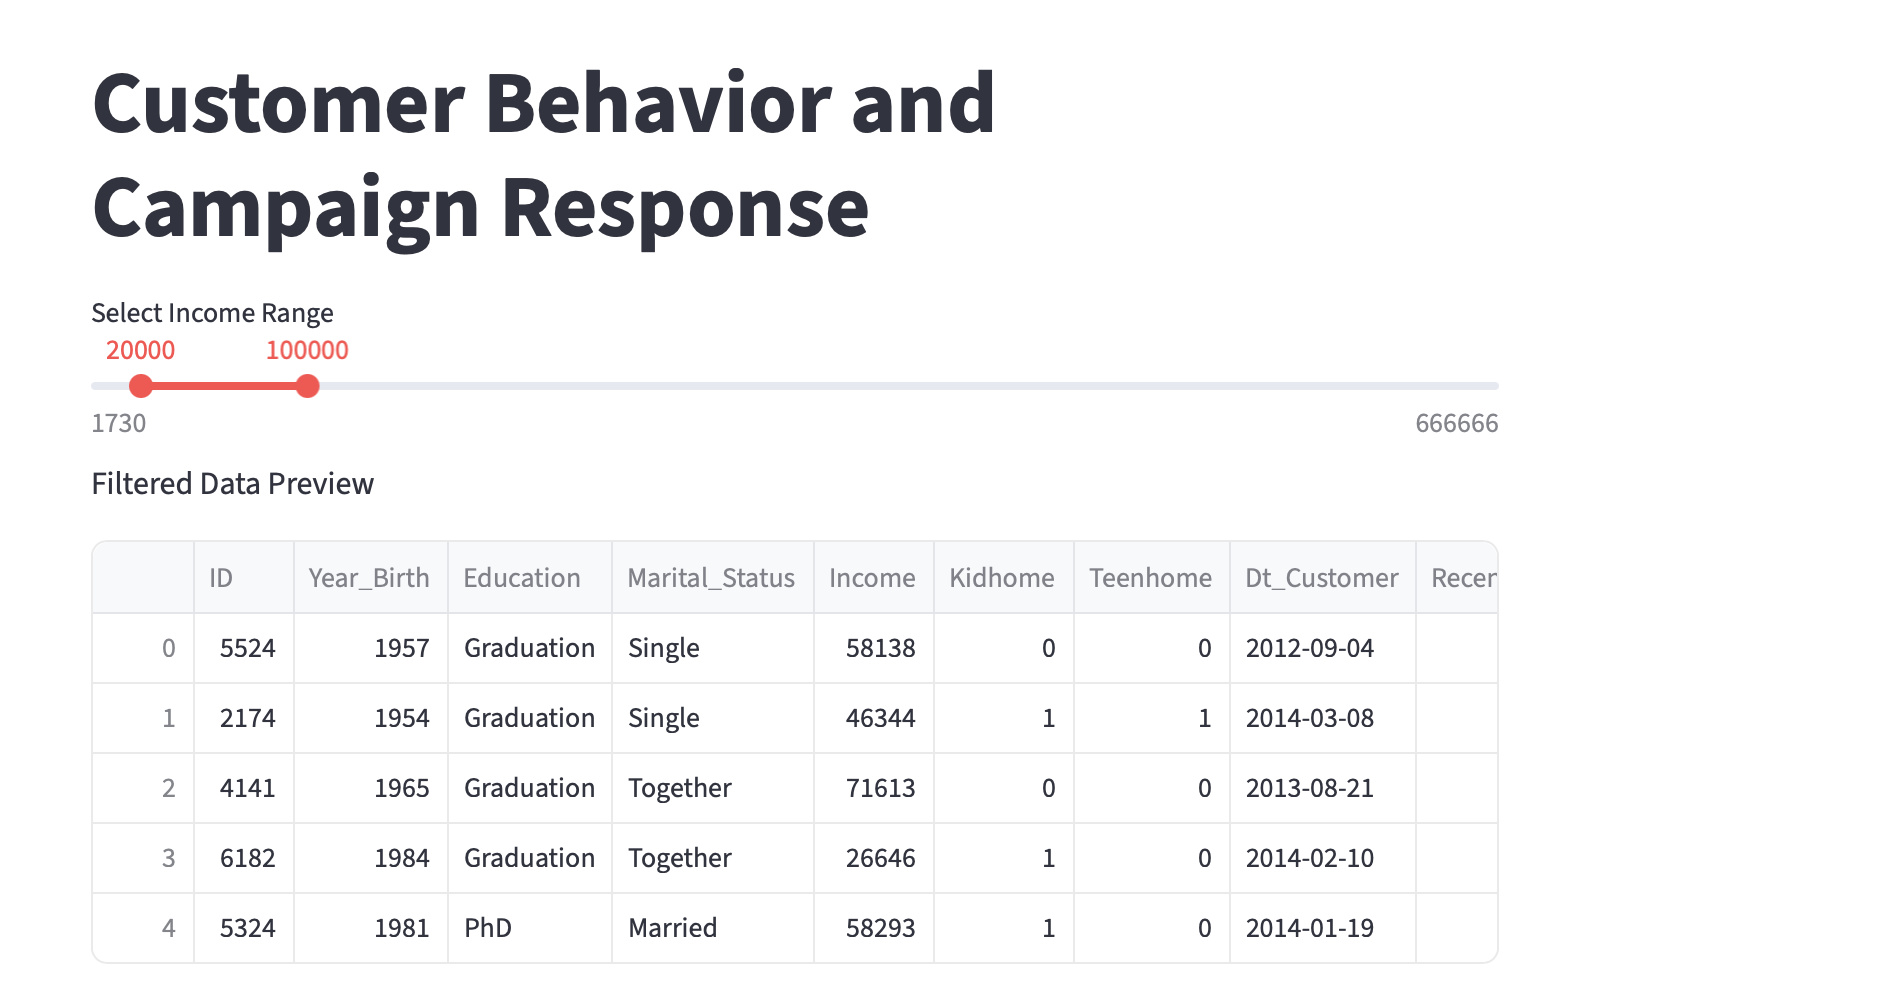

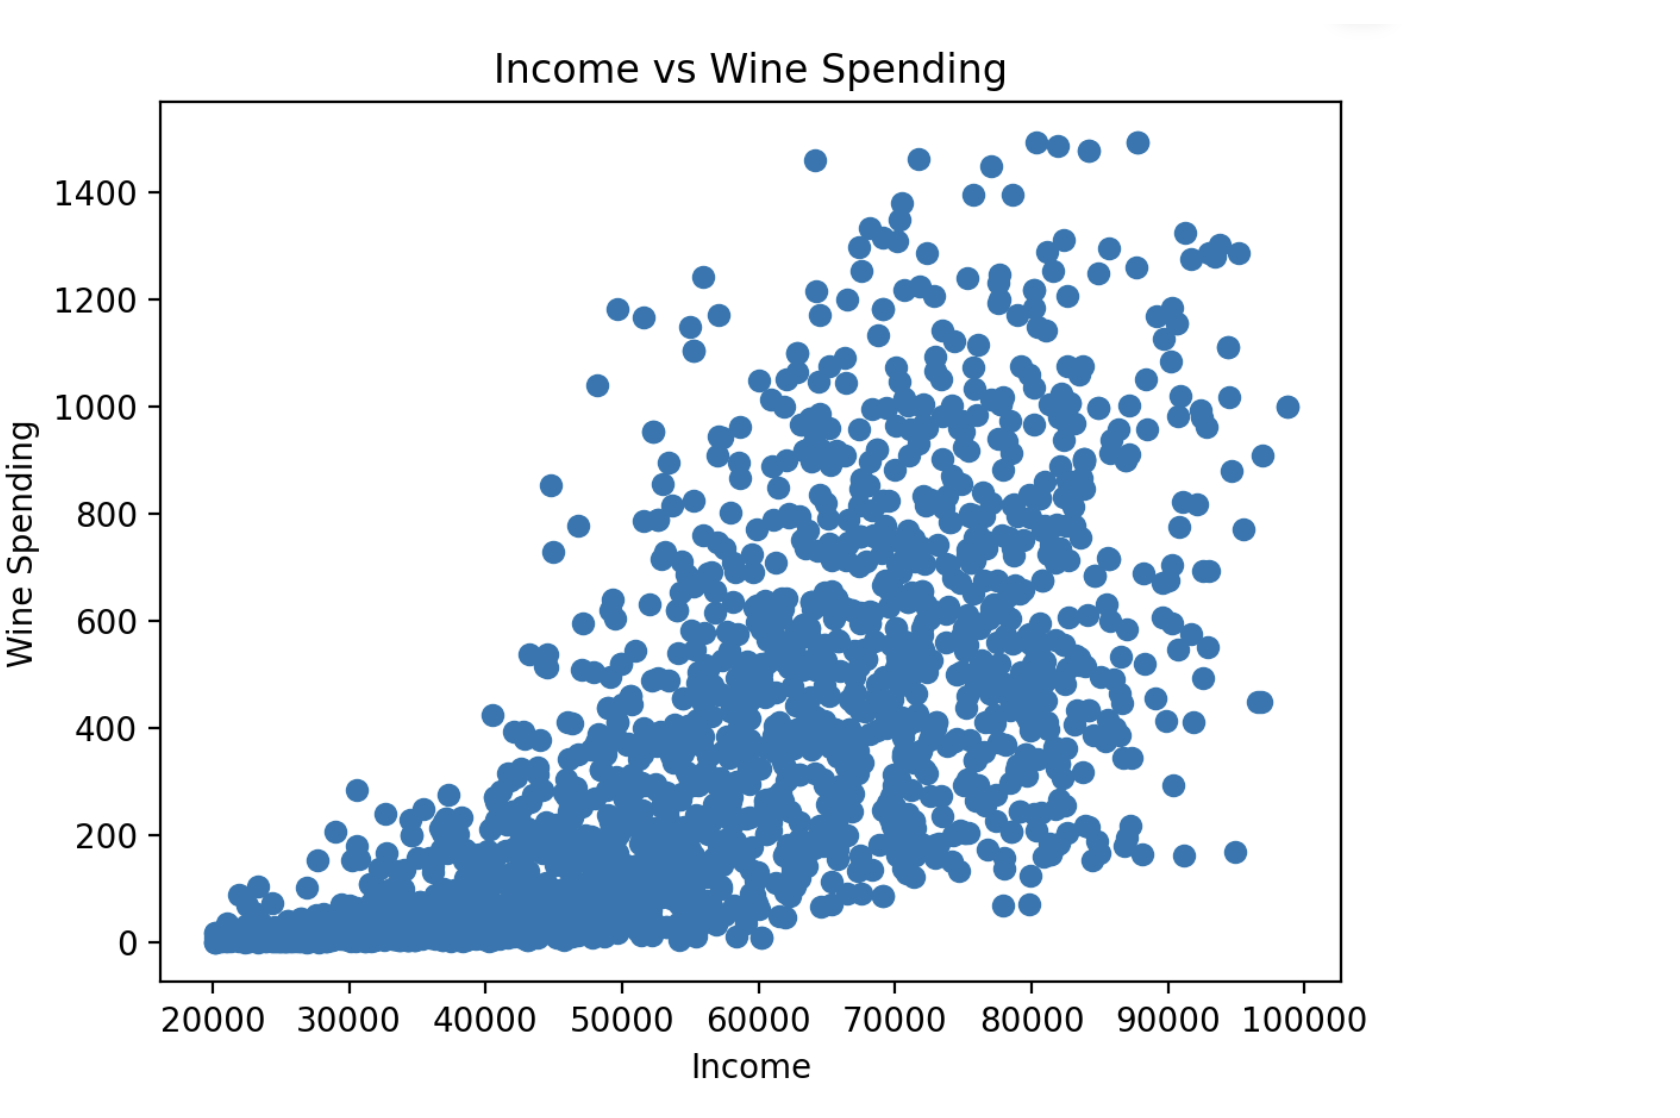